# Skincare Ingredient Conflict Predictor
## Notebook 2 : Preprocessing, Feature Engineering & Modeling


---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from sklearn.model_selection import (train_test_split, StratifiedKFold,cross_val_score, GridSearchCV)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, f1_score,precision_score, recall_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
# Project color palette
SAFE_COLOR = '#4CAF50'
RISK_COLOR = '#E53935'
ACCENT_COLOR = '#7E57C2'
BLUE_COLOR = '#1E88E5'
RANDOM_STATE = 42
print('loaded')

loaded


---
## 2. Load Data

In [2]:
df = pd.read_csv('data/ingredient_conflict_dataset.csv')
print(f'Raw dataset: {df.shape[0]:,} rows and {df.shape[1]} columns')
print(f'Conflict rate: {df["risk"].mean()*100:.1f}%')
df.head(3)

Raw dataset: 4,371 rows and 33 columns
Conflict rate: 11.4%


,ingredient_a,ingredient_b,risk,pH_a,category_a,is_acid_a,is_oxidizer_a,photosensitizing_a,exfoliant_a,barrier_repair_a,...,exfoliant_b,barrier_repair_b,anti_inflammatory_b,brightening_b,humectant_b,retinoid_b,antioxidant_b,comedogenic_b,irritation_level_b,strength_level_b
0,Retinol,Tretinoin,1,5.5,retinoid,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0
1,Retinol,Retinaldehyde,1,5.5,retinoid,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0
2,Retinol,Bakuchiol,0,5.5,retinoid,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [3]:
print(df.columns.tolist())
print(df.dtypes)

['ingredient_a', 'ingredient_b', 'risk', 'pH_a', 'category_a', 'is_acid_a', 'is_oxidizer_a', 'photosensitizing_a', 'exfoliant_a', 'barrier_repair_a', 'anti_inflammatory_a', 'brightening_a', 'humectant_a', 'retinoid_a', 'antioxidant_a', 'comedogenic_a', 'irritation_level_a', 'strength_level_a', 'pH_b', 'category_b', 'is_acid_b', 'is_oxidizer_b', 'photosensitizing_b', 'exfoliant_b', 'barrier_repair_b', 'anti_inflammatory_b', 'brightening_b', 'humectant_b', 'retinoid_b', 'antioxidant_b', 'comedogenic_b', 'irritation_level_b', 'strength_level_b']
ingredient_a            object
ingredient_b            object
risk                     int64
pH_a                   float64
category_a              object
is_acid_a              float64
is_oxidizer_a          float64
photosensitizing_a     float64
exfoliant_a            float64
barrier_repair_a       float64
anti_inflammatory_a    float64
brightening_a          float64
humectant_a            float64
retinoid_a             float64
antioxidant_a    

---
## 3. Data Preprocessing

### 3.1 Add Missing Indicators

In [4]:
df_clean = df.copy()
numeric_feat_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_feat_cols = df_clean.select_dtypes(exclude=np.number).columns.tolist()
print(f'Numeric features: {numeric_feat_cols}')
print(f'Categorical features: {categorical_feat_cols}')
# Add missing indicator flags for pH features
df_clean['features_a_missing'] = df_clean['pH_a'].isna().astype(int)
df_clean['features_b_missing'] = df_clean['pH_b'].isna().astype(int)
print('Missing indicators added:')
print(f"features_a_missing=1: {df_clean['features_a_missing'].sum():,} rows")
print(f"features_b_missing=1: {df_clean['features_b_missing'].sum():,} rows")
print()


Numeric features: ['risk', 'pH_a', 'is_acid_a', 'is_oxidizer_a', 'photosensitizing_a', 'exfoliant_a', 'barrier_repair_a', 'anti_inflammatory_a', 'brightening_a', 'humectant_a', 'retinoid_a', 'antioxidant_a', 'comedogenic_a', 'irritation_level_a', 'strength_level_a', 'pH_b', 'is_acid_b', 'is_oxidizer_b', 'photosensitizing_b', 'exfoliant_b', 'barrier_repair_b', 'anti_inflammatory_b', 'brightening_b', 'humectant_b', 'retinoid_b', 'antioxidant_b', 'comedogenic_b', 'irritation_level_b', 'strength_level_b']
Categorical features: ['ingredient_a', 'ingredient_b', 'category_a', 'category_b']
Missing indicators added:
features_a_missing=1: 641 rows
features_b_missing=1: 1,219 rows



### 3.2 Encode Categorical Features


In [5]:
# Encode category_a and category_b
le = LabelEncoder()
all_cats = pd.concat([df_clean['category_a'], df_clean['category_b']]).dropna()
le.fit(all_cats)
df_clean['category_a_enc'] = df_clean['category_a'].map(lambda x: le.transform([x])[0] if pd.notna(x) else -1)
df_clean['category_b_enc'] = df_clean['category_b'].map(lambda x: le.transform([x])[0] if pd.notna(x) else -1)
# we drop text columns (names + original category text)
df_clean = df_clean.drop(columns=['ingredient_a', 'ingredient_b', 'category_a', 'category_b'])

print(f'Dataset shape after encoding: {df_clean.shape}')
print(f'Category encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Dataset shape after encoding: (4371, 33)
Category encoding: {'AHA': np.int64(0), 'BHA': np.int64(1), 'PHA': np.int64(2), 'antimicrobial': np.int64(3), 'antioxidant': np.int64(4), 'brightening': np.int64(5), 'humectant': np.int64(6), 'lipid': np.int64(7), 'mineral': np.int64(8), 'peptide': np.int64(9), 'protein': np.int64(10), 'retinoid': np.int64(11), 'soothing': np.int64(12), 'stimulant': np.int64(13), 'vitamin': np.int64(14)}


### 3.3 Impute Missing Numeric Values using IterativeImputer

In [6]:

rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
imputer= IterativeImputer(estimator=rf, max_iter=10, random_state=RANDOM_STATE)
df_clean[numeric_feat_cols] = imputer.fit_transform(df_clean[numeric_feat_cols])
print(f'Missing values after numeric imputation: {df_clean[numeric_feat_cols].isnull().sum().sum()}')

C:\Users\MSI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Missing values after numeric imputation: 0


In [7]:
print(df_clean.head(3))

   risk  pH_a  is_acid_a  is_oxidizer_a  photosensitizing_a  exfoliant_a  \
0   1.0   5.5        0.0            0.0                 1.0          0.0   
1   1.0   5.5        0.0            0.0                 1.0          0.0   
2   0.0   5.5        0.0            0.0                 1.0          0.0   

   barrier_repair_a  anti_inflammatory_a  brightening_a  humectant_a  ...  \
0               0.0                  0.0            1.0          0.0  ...   
1               0.0                  0.0            1.0          0.0  ...   
2               0.0                  0.0            1.0          0.0  ...   

   humectant_b  retinoid_b  antioxidant_b  comedogenic_b  irritation_level_b  \
0          0.0         1.0            0.0            0.0                 2.0   
1          0.0         1.0            0.0            0.0                 1.0   
2          0.0         1.0            0.0            0.0                 0.0   

   strength_level_b  features_a_missing  features_b_missing  cate

---
## 4. Feature Engineering

 we created **11 new features** to understand better how 2 ingredients interact with each other
Those features are important for our project because the model can't learn and understand the interaction by looking at each ingredient feature separately 


In [8]:
# 1. pH difference 
df_clean['pH_diff'] = abs(df_clean['pH_a'] - df_clean['pH_b'])
# 2. Combined irritation score
df_clean['combined_irritation'] = df_clean['irritation_level_a'] + df_clean['irritation_level_b']
# 3. Combined strength score
df_clean['combined_strength'] = df_clean['strength_level_a'] + df_clean['strength_level_b']
# 4. Double retinoid
df_clean['both_retinoid'] = (df_clean['retinoid_a'] * df_clean['retinoid_b'])
# 5. Double exfoliant 
df_clean['both_exfoliant'] = (df_clean['exfoliant_a'] * df_clean['exfoliant_b'])
# 6. Both acidic 
df_clean['both_acid'] = (df_clean['is_acid_a'] * df_clean['is_acid_b'])
# 7. Oxidizer present in the pair
df_clean['oxidizer_count'] = (df_clean['is_oxidizer_a'] + df_clean['is_oxidizer_b'])
# 8. Both photosensitizing 
df_clean['photo_sensitive_pair'] = (df_clean['photosensitizing_a'] * df_clean['photosensitizing_b'])
# 9. Interaction of strength and irritation 
df_clean['strong_irritant_combo'] = (df_clean['strength_level_a'] * df_clean['irritation_level_b'] +
    df_clean['strength_level_b'] * df_clean['irritation_level_a'])
#10. Interaction of acid and exfoliant
df_clean['acid_exfoliant_interaction'] = (df_clean['is_acid_a'] * df_clean['exfoliant_b'] +df_clean['is_acid_b'] * df_clean['exfoliant_a'])
#11. pH risk 
df_clean['pH_risk'] = np.maximum( np.abs(df_clean['pH_a'] - 5), np.abs(df_clean['pH_b'] - 5))
new_features = ['pH_diff', 'combined_irritation', 'combined_strength','both_retinoid', 
                'both_exfoliant', 'both_acid','oxidizer_count', 'photo_sensitive_pair', 'strong_irritant_combo',
                  'acid_exfoliant_interaction',  'pH_risk']
print('New engineered features:')
for f in new_features:
    corr = df_clean[f].corr(df_clean['risk'])
    print(f'  {f:<25} => correlation with risk: {corr:+.3f}')

New engineered features:
  pH_diff                   => correlation with risk: +0.156
  combined_irritation       => correlation with risk: +0.502
  combined_strength         => correlation with risk: +0.511
  both_retinoid             => correlation with risk: +0.022
  both_exfoliant            => correlation with risk: +0.251
  both_acid                 => correlation with risk: +0.276
  oxidizer_count            => correlation with risk: +0.280
  photo_sensitive_pair      => correlation with risk: +0.436
  strong_irritant_combo     => correlation with risk: +0.600
  acid_exfoliant_interaction => correlation with risk: +0.286
  pH_risk                   => correlation with risk: -0.044


### 4.1 Validate Engineered Features

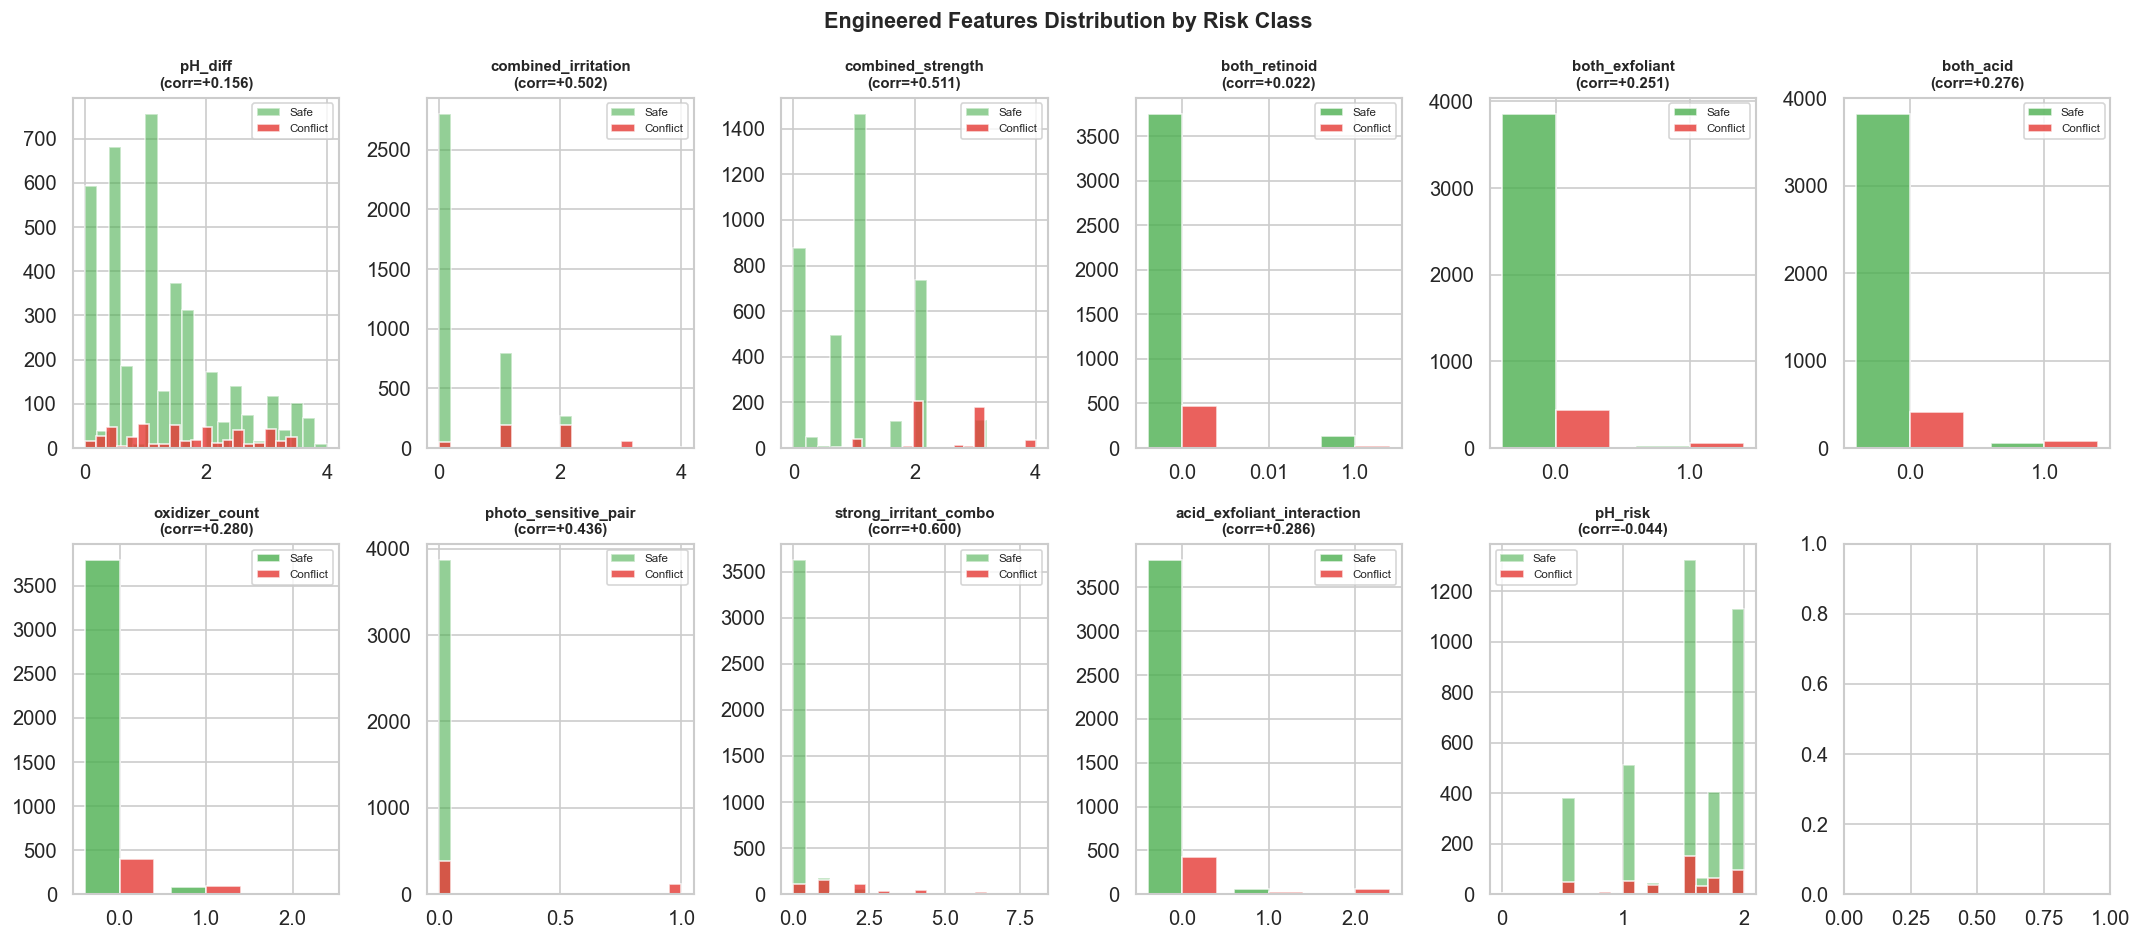

In [9]:
fig, axes = plt.subplots(2, 6, figsize=(18, 8))

for ax, feat in zip(axes.flat, new_features):
    safe_vals    = df_clean[df_clean['risk']==0][feat]
    conflict_vals = df_clean[df_clean['risk']==1][feat]
    
    if df_clean[feat].nunique() <= 4: 
        vals = sorted(df_clean[feat].unique())
        safe_c    = [safe_vals.value_counts().get(v, 0) for v in vals]
        conflict_c = [conflict_vals.value_counts().get(v, 0) for v in vals]
        x = np.arange(len(vals))
        ax.bar(x - 0.2, safe_c,    0.4, color=SAFE_COLOR, alpha=0.8, label='Safe')
        ax.bar(x + 0.2, conflict_c, 0.4, color=RISK_COLOR, alpha=0.8, label='Conflict')
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in vals])
    else:  # continuous
        ax.hist(safe_vals, bins=20, alpha=0.6, color=SAFE_COLOR, label='Safe', edgecolor='white')
        ax.hist(conflict_vals, bins=20, alpha=0.8, color=RISK_COLOR, label='Conflict', edgecolor='white')
    
    corr = df_clean[feat].corr(df_clean['risk'])
    ax.set_title(f'{feat}\n(corr={corr:+.3f})', fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Engineered Features Distribution by Risk Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/15_engineered_features_distribution.png', bbox_inches='tight')
plt.show()

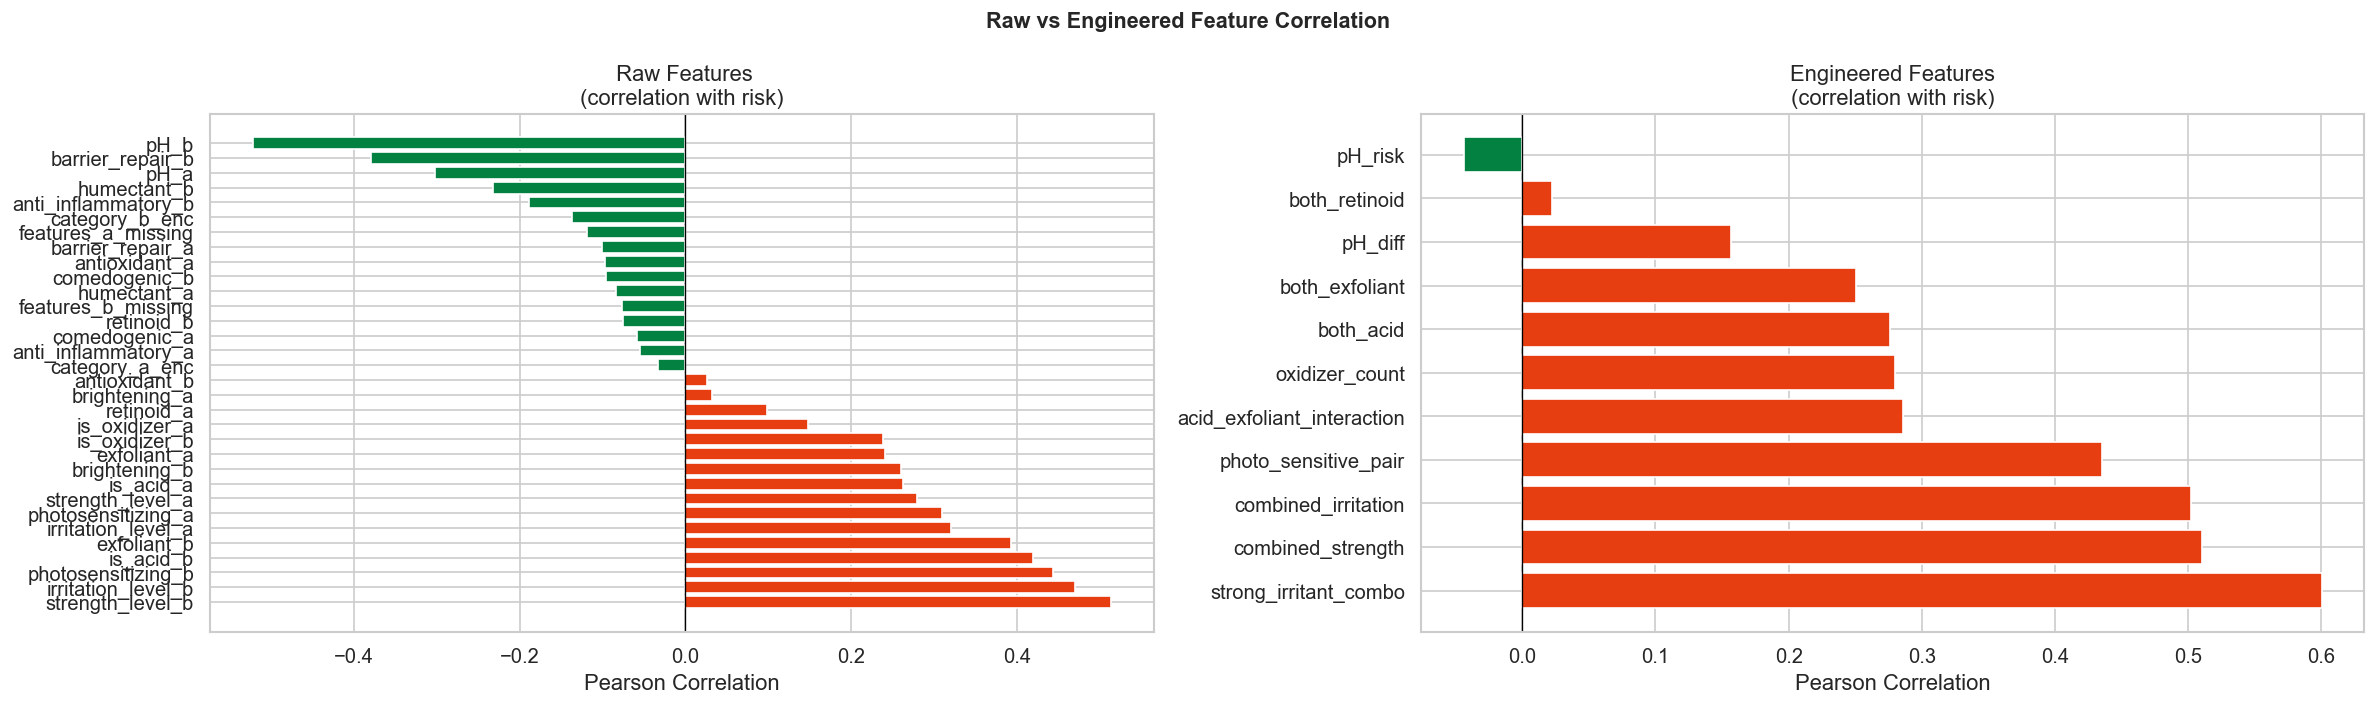

In [10]:
#visualize correlation of all features with risk
numeric_df = df_clean.select_dtypes(include=[np.number])
raw_features = [c for c in numeric_df.columns if c not in new_features and c != 'risk' ]
raw_corr = df_clean[raw_features + ['risk']].corr()['risk'].drop('risk').sort_values()
eng_corr= df_clean[new_features + ['risk']].corr()['risk'].drop('risk').sort_values()
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, corr, title in zip(axes,[raw_corr, eng_corr],[' Raw Features', 'Engineered Features']):
    colors = ['#E63E11' if v > 0 else '#038141' for v in corr.values]
    ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{title}\n(correlation with risk)')
    ax.set_xlabel('Pearson Correlation')
plt.suptitle('Raw vs Engineered Feature Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
features = df_clean.select_dtypes(include=[np.number])
corr_matrix = features.corr().abs()
# Upper triangle to avoid duplicates
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find features with high correlation
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
print(f"Removed {len(to_drop)} highly correlated features")

Removed 0 highly correlated features


### 5. Train / Test Split

In [12]:
X = df_clean.drop(columns=['risk'])
y = df_clean['risk']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,stratify=y, random_state=RANDOM_STATE)
print(f'Training set:{X_train.shape[0]:,} samples  ({y_train.mean()*100:.1f}% conflict)')
print(f'Test set:{X_test.shape[0]:,} samples  ({y_test.mean()*100:.1f}% conflict)')

Training set:3,496 samples  (11.4% conflict)
Test set:875 samples  (11.4% conflict)


### 6. Handle Class Imbalance with SMOTE

Our dataset has **88.6% safe / 11.4% conflict** so it 's highly imbalanced
We apply **SMOTE** (Synthetic Minority Over-sampling Technique) on the **training set only** to avoid data leakage

In [13]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smo, y_train_smo = smote.fit_resample(X_train, y_train)
print('Before SMOTE:')
vals, cnts = np.unique(y_train, return_counts=True)
for v, c in zip(vals, cnts):
    print(f'  Class {v}: {c:,} samples ({c/len(y_train)*100:.1f}%)')

print('\nAfter SMOTE:')
vals, cnts = np.unique(y_train_smo, return_counts=True)
for v, c in zip(vals, cnts):
    print(f'  Class {v}: {c:,} samples ({c/len(y_train_smo)*100:.1f}%)')
# Standardize for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smo)
X_test_scaled  = scaler.transform(X_test)

Before SMOTE:
  Class 0.0: 3,098 samples (88.6%)
  Class 1.0: 398 samples (11.4%)

After SMOTE:
  Class 0.0: 3,098 samples (50.0%)
  Class 1.0: 3,098 samples (50.0%)


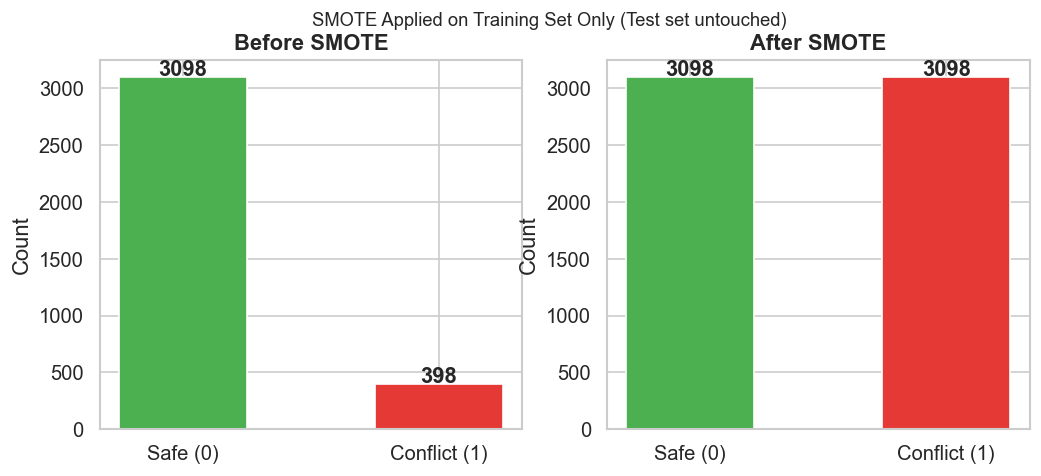

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(axes,
    [y_train.value_counts(), y_train_smo.value_counts()],
    ['Before SMOTE', 'After SMOTE']):
    ax.bar(['Safe (0)', 'Conflict (1)'], counts.sort_index().values,
           color=[SAFE_COLOR, RISK_COLOR], edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.sort_index().values):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.suptitle('SMOTE Applied on Training Set Only (Test set untouched)', fontsize=11)
plt.show()

---
## 6. Modeling

### 6.1 Logistic Regression (Linear Baseline)

In [15]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train_smo)
y_pred_lr= lr.predict(X_test_scaled)
y_proba_lr= lr.predict_proba(X_test_scaled)[:, 1]
print("Model 1 : Logistic Regression")
print(classification_report(y_test, y_pred_lr, target_names=['Safe (0)', 'Conflict (1)']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_lr):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_lr):.4f}')


Model 1 : Logistic Regression
              precision    recall  f1-score   support

    Safe (0)       0.99      0.95      0.97       775
Conflict (1)       0.72      0.93      0.81       100

    accuracy                           0.95       875
   macro avg       0.85      0.94      0.89       875
weighted avg       0.96      0.95      0.95       875

ROC-AUC: 0.9853
F1-Score: 0.8087
Recall: 0.9300


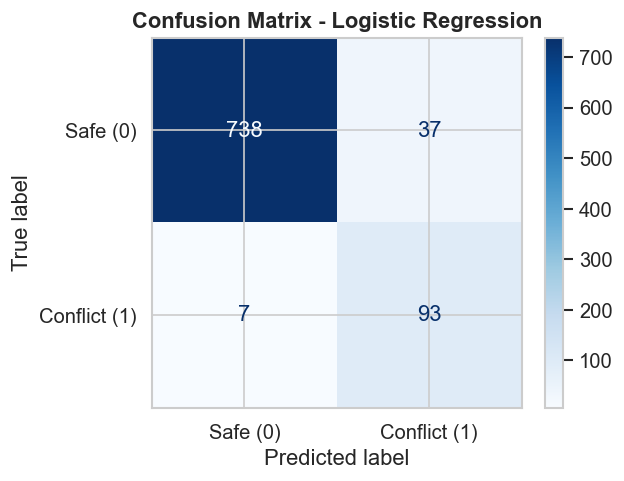

In [16]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Safe (0)', 'Conflict (1)']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression', fontweight='bold')
plt.show()


### 6.2 Decision Tree

In [17]:
dt = DecisionTreeClassifier(max_depth=10,class_weight='balanced',random_state=RANDOM_STATE)
dt.fit(X_train_smo, y_train_smo)
y_pred_dt = dt.predict(X_test)
y_proba_dt= dt.predict_proba(X_test)[:, 1]
print("Model 2 : Decision Tree")
print(classification_report(y_test, y_pred_dt, target_names=['Safe (0)', 'Conflict (1)']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_dt):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_dt):.4f}')
print(f'Recall : {recall_score(y_test, y_pred_dt):.4f}')


Model 2 : Decision Tree
              precision    recall  f1-score   support

    Safe (0)       1.00      0.99      1.00       775
Conflict (1)       0.95      0.98      0.97       100

    accuracy                           0.99       875
   macro avg       0.97      0.99      0.98       875
weighted avg       0.99      0.99      0.99       875

ROC-AUC: 0.9875
F1-Score: 0.9655
Recall : 0.9800


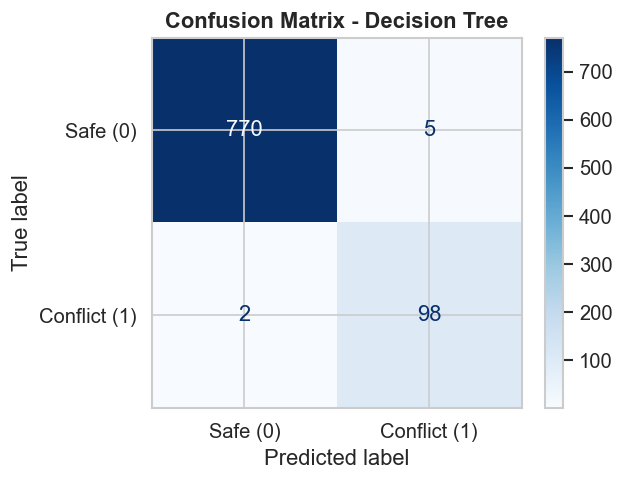

In [18]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Safe (0)', 'Conflict (1)']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Decision Tree', fontweight='bold')
plt.show()

### 6.3 Random Forest

In [19]:
rf = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1)
rf.fit(X_train_smo, y_train_smo)
y_pred_rf = rf.predict(X_test)
y_proba_rf= rf.predict_proba(X_test)[:, 1]
print("Model 3 : Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=['Safe (0)', 'Conflict (1)']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_rf):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_rf):.4f}')

Model 3 : Random Forest
              precision    recall  f1-score   support

    Safe (0)       1.00      1.00      1.00       775
Conflict (1)       0.97      0.99      0.98       100

    accuracy                           1.00       875
   macro avg       0.98      0.99      0.99       875
weighted avg       1.00      1.00      1.00       875

ROC-AUC: 0.9935
F1-Score: 0.9802
Recall: 0.9900


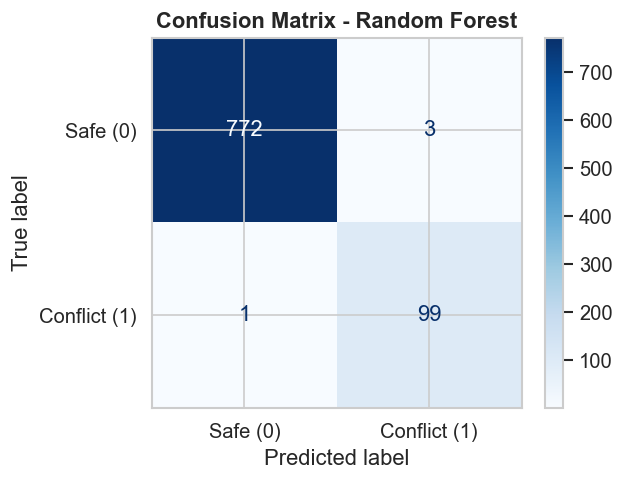

In [20]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Safe (0)', 'Conflict (1)']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Random Forest', fontweight='bold')
plt.show()

### 6.4 XGBoost

In [21]:
from xgboost import XGBClassifier
xg= XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss',  verbosity=0)
xg.fit(X_train_smo, y_train_smo)
y_pred_xg = xg.predict(X_test)
print("Model 4 : XGBoost")
print(classification_report(y_test, y_pred_xg, target_names=['Safe (0)', 'Conflict (1)']))  
print(f'ROC-AUC: {roc_auc_score(y_test, xg.predict_proba(X_test)[:, 1]):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_xg):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_xg):.4f}')

Model 4 : XGBoost
              precision    recall  f1-score   support

    Safe (0)       0.99      1.00      0.99       775
Conflict (1)       0.97      0.95      0.96       100

    accuracy                           0.99       875
   macro avg       0.98      0.97      0.98       875
weighted avg       0.99      0.99      0.99       875

ROC-AUC: 0.9929
F1-Score: 0.9596
Recall: 0.9500


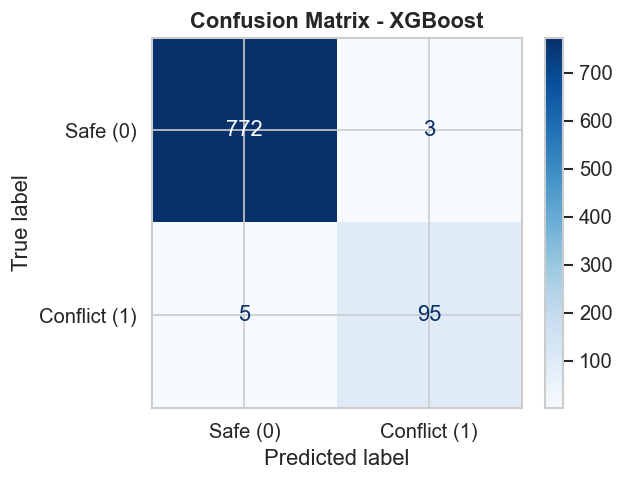

In [22]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred_xg)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Safe (0)', 'Conflict (1)']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - XGBoost', fontweight='bold')
plt.show()

### 6.5 Cross Validation for Models Stability

5-Fold Cross-Validation (Recall):
  Logistic Regression         : 0.9839 ± 0.0059  [0.97580645 0.99192246 0.98869144 0.98387097 0.97903226]
  Decision Tree               : 0.9919 ± 0.0023  [0.99516129 0.98869144 0.99192246 0.99354839 0.99032258]
  Random Forest               : 0.9977 ± 0.0013  [0.9983871  0.99838449 0.99515347 0.9983871  0.9983871 ]
  XGBoost                     : 0.9981 ± 0.0006  [0.9983871  0.99838449 0.99838449 0.99677419 0.9983871 ]


C:\Users\MSI\AppData\Local\Temp\ipykernel_19888\385212786.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


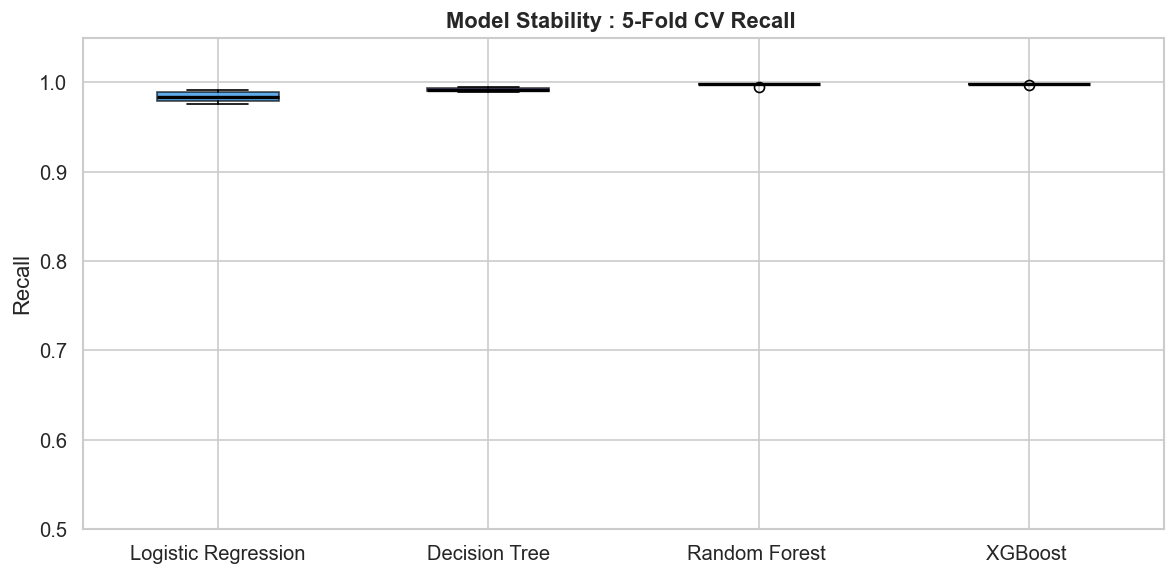

In [23]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results_all = {}
models_cv = [
    ('Logistic Regression', lr),
    ('Decision Tree', dt),
    ('Random Forest ',rf),
    ('XGBoost ', xg)]

print('5-Fold Cross-Validation (Recall):')
for name, model in models_cv:
    if name == 'Logistic Regression':
        scores = cross_val_score(model, X_train_scaled, y_train_smo, cv=cv_strat, scoring='recall')
    else:
        scores = cross_val_score(model, X_train_smo, y_train_smo, cv=cv_strat, scoring='recall')
    cv_results_all[name] = scores
    print(f'  {name:<28}: {scores.mean():.4f} ± {scores.std():.4f}  {scores}')

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    [cv_results_all[n] for n, _ in models_cv],
    labels=[n for n, _ in models_cv],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], [BLUE_COLOR, ACCENT_COLOR, RISK_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Recall')
ax.set_title('Model Stability : 5-Fold CV Recall ', fontweight='bold')
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

---
## 7. Model Comparison

In [24]:
models_info = [
    ('Logistic Regression', y_pred_lr, y_proba_lr),
    ('Decision Tree',y_pred_dt, y_proba_dt),
    ('Random Forest',y_pred_rf, y_proba_rf),
    ('XGBoost', y_pred_xg, xg.predict_proba(X_test)[:, 1])
]

results = []
for name, y_pred, y_proba in models_info:
    results.append({
        'Model': name,
        'Accuracy':  round((y_pred == y_test).mean(), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':round(roc_auc_score(y_test, y_proba), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('Model Comparison:')
print(results_df.to_string())
print('\n Best Models per metric:')
for col in results_df.columns:
    best_model = results_df[col].idxmax()
    print(f'{col:<18}: {best_model} ({results_df.loc[best_model, col]:.4f})')


Model Comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.9497     0.7154    0.93    0.8087   0.9853
Decision Tree          0.9920     0.9515    0.98    0.9655   0.9875
Random Forest          0.9954     0.9706    0.99    0.9802   0.9935
XGBoost                0.9909     0.9694    0.95    0.9596   0.9929

 Best Models per metric:
Accuracy          : Random Forest (0.9954)
Precision         : Random Forest (0.9706)
Recall            : Random Forest (0.9900)
F1 Score          : Random Forest (0.9802)
ROC-AUC           : Random Forest (0.9935)


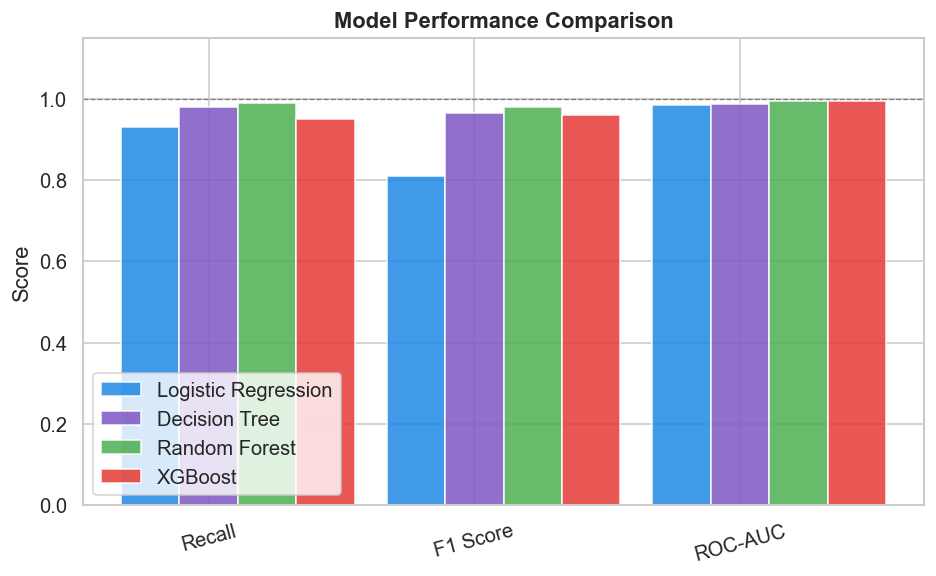

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Metric comparison bar chart
metrics_to_plot = [ 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.22
colors = [BLUE_COLOR, ACCENT_COLOR, SAFE_COLOR, RISK_COLOR]

fig, ax = plt.subplots(figsize=(8, 5))

for i, (row_name, color) in enumerate(zip(results_df.index, colors)):
    vals = results_df.loc[row_name, metrics_to_plot].values
    ax.bar(x + i*width, vals, width, label=row_name,
           color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, rotation=15)
ax.set_ylim(0, 1.15)
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.legend()
ax.set_ylabel('Score')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('figures/16_model_comparison.png', bbox_inches='tight')
plt.show()

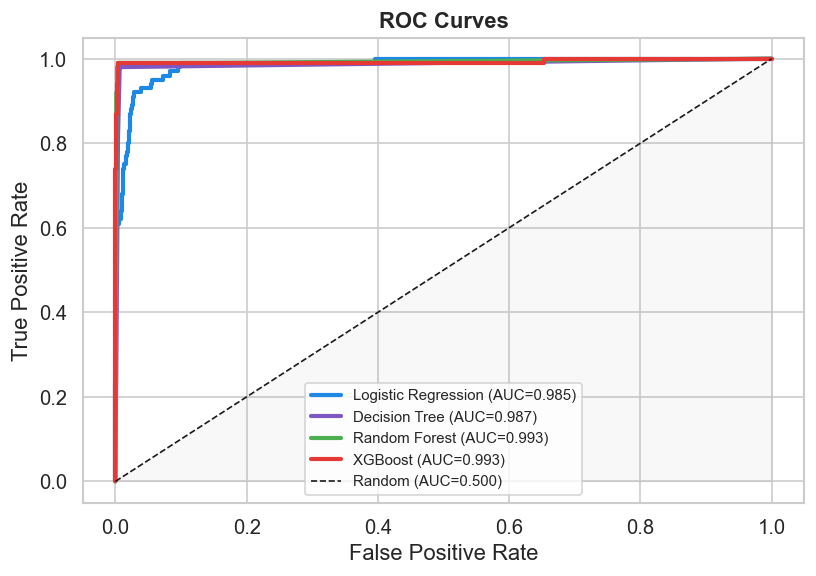

In [26]:
plt.figure(figsize=(7, 5))

for (name, y_pred, y_proba), color in zip(models_info, colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves', fontweight='bold')
plt.legend(fontsize=9)
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.tight_layout()
plt.show()

---
## 8. Hyperparameter Optimization on Random Forest


In [27]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

rf_base = RandomForestClassifier(class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_smo, y_train_smo)
print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV recall: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV recall: 0.9984


### 8.1 Evaluate Optimized Model

In [28]:
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
print('Tuned Random Forest (Best Model)')
print(f'ROC-AUC: {auc_best:.4f}')
print(f'F1-Score: {f1_best:.4f}')
print(f'Recall: {recall_best:.4f}')
print(classification_report(y_test, y_pred_best, target_names=['Safe (0)', 'Conflict (1)']))

# Improvement 
metrics_imp= [
    {'Metric': 'Recall', 'Before': recall_score(y_test, y_pred_rf), 'After': recall_best},
    {'Metric': 'F1 Score', 'Before': f1_score(y_test, y_pred_rf), 'After': f1_best},
    {'Metric': 'ROC-AUC', 'Before': roc_auc_score(y_test, y_proba_rf), 'After': auc_best}
]
for m in metrics_imp:
    before = m['Before']
    after = m['After']
    print(f"{m['Metric']:<18}: {before:.4f} => {after:.4f} ({after-before:+.4f})")

Tuned Random Forest (Best Model)
ROC-AUC: 0.9922
F1-Score: 0.9754
Recall: 0.9900
              precision    recall  f1-score   support

    Safe (0)       1.00      0.99      1.00       775
Conflict (1)       0.96      0.99      0.98       100

    accuracy                           0.99       875
   macro avg       0.98      0.99      0.99       875
weighted avg       0.99      0.99      0.99       875

Recall            : 0.9900 => 0.9900 (+0.0000)
F1 Score          : 0.9802 => 0.9754 (-0.0048)
ROC-AUC           : 0.9935 => 0.9922 (-0.0013)


### 8.2 Cross Validation

Recall    : [0.9984 0.9968 0.9984 0.9984 1.    ] => mean=0.9984  std=0.0010
F1        : [0.9952 0.992  0.9968 0.9968 0.9952] => mean=0.9952  std=0.0018
ROC-AUC   : [0.9998 0.9999 1.     1.     0.9999] => mean=0.9999  std=0.0000
Gap: 0.0084 =>  No overfitting


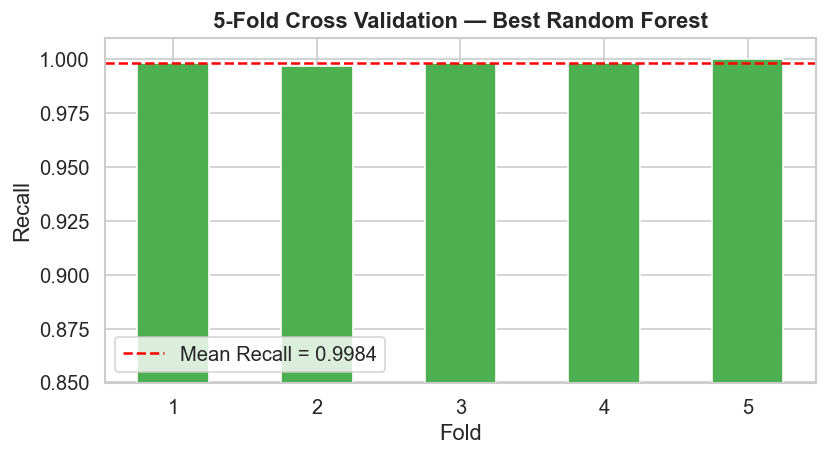

In [29]:

best_rf = grid_search.best_estimator_
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results=[]
for metric, scoring in [('Recall', 'recall'), ('F1', 'f1'), ('ROC-AUC', 'roc_auc')]:
    scores = cross_val_score(best_rf, X_train_smo, y_train_smo,cv=cv, scoring=scoring, n_jobs=-1)
    cv_results.append({
        'Metric': metric,
        'Scores': scores,
        'Mean': scores.mean(),
        'Std': scores.std()
    })
    print(f'{metric:10}: {scores.round(4)} => mean={scores.mean():.4f}  std={scores.std():.4f}')

# Plot CV Recall scores
recall_scores = cross_val_score(best_rf, X_train_smo, y_train_smo,cv=cv, scoring='recall', n_jobs=-1)
gap=abs(recall_scores.mean() - recall_best)
print(f'Gap: {gap:.4f} => {" No overfitting" if gap < 0.03 else "Check overfitting"}')
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), recall_scores, color=SAFE_COLOR,
       edgecolor='white', width=0.5)
ax.axhline(recall_scores.mean(), color='red', linestyle='--',
           label=f'Mean Recall = {recall_scores.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Recall')
ax.set_title('5-Fold Cross Validation — Best Random Forest', fontweight='bold')
ax.set_ylim(0.85, 1.01)
ax.legend()
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150)
plt.show()

---
## 9. Model Interpretation

### 9.1 Feature Importance

Feature importance ranking:

strong_irritant_combo         0.147815
strength_level_b              0.101876
combined_strength             0.096061
pH_b                          0.076808
combined_irritation           0.064918
barrier_repair_b              0.059995
category_b_enc                0.044964
pH_a                          0.034309
humectant_b                   0.034210
irritation_level_a            0.033518
brightening_b                 0.030410
irritation_level_b            0.029322
pH_diff                       0.029101
strength_level_a              0.024528
is_acid_a                     0.023761
antioxidant_b                 0.021589
exfoliant_a                   0.016896
category_a_enc                0.015207
photosensitizing_a            0.012731
anti_inflammatory_b           0.011874
pH_risk                       0.009970
photosensitizing_b            0.009917
is_acid_b                     0.009574
features_b_missing            0.006378
brightening_a                 0.005

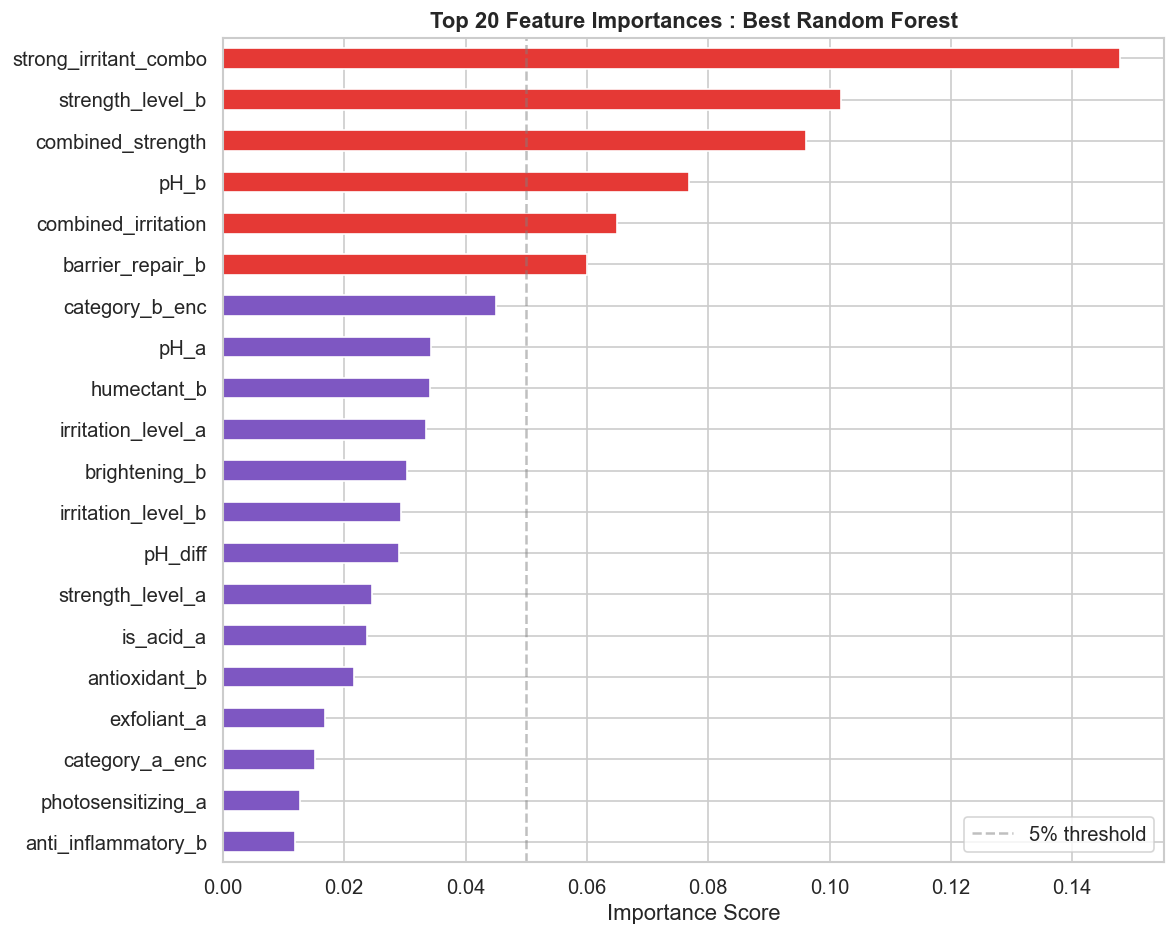

In [30]:
best_rf.fit(X_train_smo, y_train_smo)
importances = pd.Series(best_rf.feature_importances_,index=X_train_smo.columns)
importances = importances.sort_values(ascending=False)
print("Feature importance ranking:\n")
print(importances.to_string())
# Plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importances.head(20).sort_values()
colors = [RISK_COLOR if v > 0.05 else ACCENT_COLOR for v in top20.values]
top20.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 20 Feature Importances : Best Random Forest',fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(0.05, color='gray', linestyle='--',alpha=0.5, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150)
plt.show()

### 9.2 Error Analysis : 

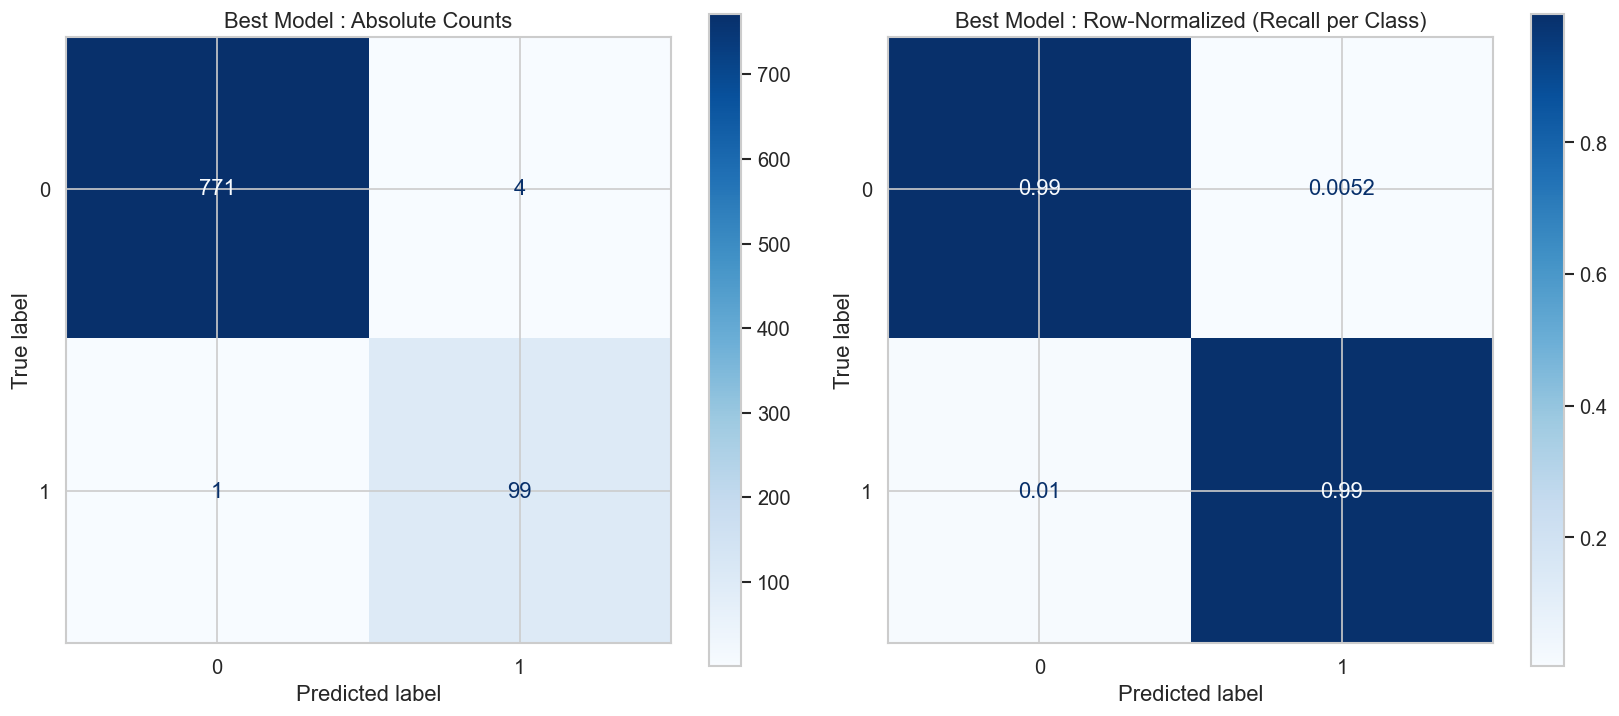

Recall per class:
  Grade Safe (0): 99.5% correctly classified
  Grade Conflict (1): 99.0% correctly classified


In [31]:
#Best Model Normalized confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best),).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Best Model : Absolute Counts')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best, normalize='true'),).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Best Model : Row-Normalized (Recall per Class)')
plt.tight_layout()
plt.show()
cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
print('Recall per class:')
for i, g in enumerate(['Safe (0)', 'Conflict (1)']):
    print(f'  Grade {g}: {cm_norm[i,i]*100:.1f}% correctly classified')

In [32]:
err= X_test[y_test != y_pred_best].copy()
y_pred_best_series = pd.Series(y_pred_best, index=X_test.index)
err['actual'] = y_test[y_test != y_pred_best]
err['predicted'] = y_pred_best_series[y_test != y_pred_best_series]
print(f'Total misclassified samples: {len(err):,}')
print("Some examples of misclassified products:")
print(err.head())
#Analyze which features contributed most to the misclassifications by comparing average feature values of misclassified vs correctly classified samples
correct = X_test[y_test == y_pred_best].copy()
comparison = pd.DataFrame({
     'Erreurs': err.drop(['actual','predicted'], axis=1).mean(),
    'Correctes': correct.mean()
})
print(comparison.sort_values('Erreurs', key=abs, ascending=False).head(10))

Total misclassified samples: 5
Some examples of misclassified products:
          pH_a  is_acid_a  is_oxidizer_a  photosensitizing_a  exfoliant_a  \
2346  3.000000        1.0            1.0                 0.0          0.0   
2355  5.337250        0.0            0.0                 0.0          0.0   
1513  4.000000        1.0            0.0                 0.0          1.0   
4109  5.343339        0.0            0.0                 0.0          0.0   
1735  4.000000        1.0            0.0                 0.0          0.0   

      barrier_repair_a  anti_inflammatory_a  brightening_a  humectant_a  \
2346               0.0                  0.0            1.0          0.0   
2355               0.0                  0.0            1.0          0.0   
1513               1.0                  1.0            0.0          0.0   
4109               0.0                  0.0            1.0          0.0   
1735               0.0                  0.0            1.0          0.0   

      retinoid

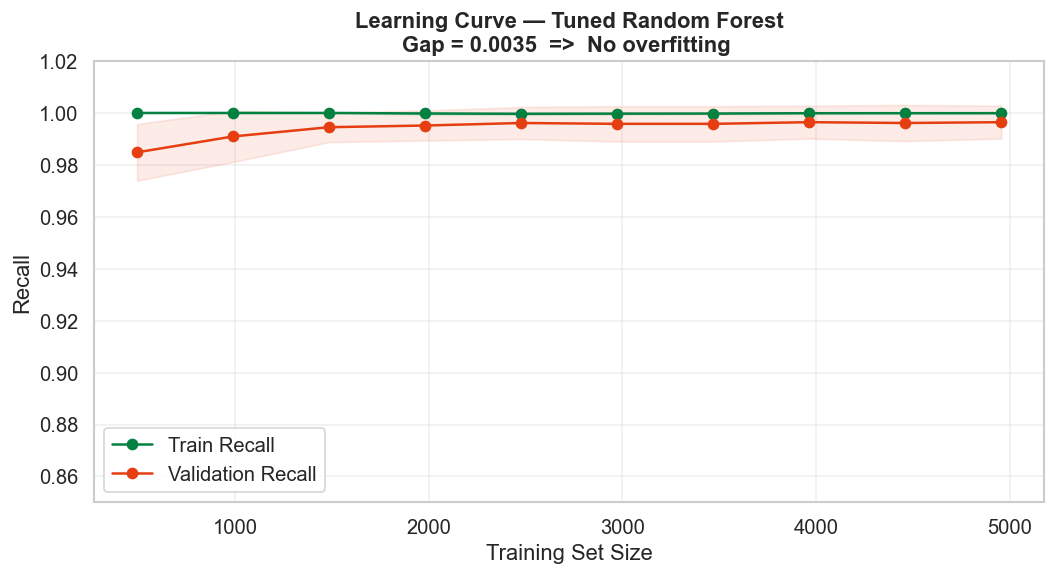

In [33]:
from sklearn.model_selection import learning_curve
fig, ax = plt.subplots(figsize=(9, 5))
train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    X_train_smo,   # SMOTE data
    y_train_smo,   
    cv=5,
    scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
train_std= train_scores.std(axis=1)
val_mean  = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)
ax.plot(train_sizes, train_mean, 'o-', color='#038141', label='Train Recall')
ax.fill_between(train_sizes,train_mean - train_std,train_mean + train_std,alpha=0.1, color='#038141')
ax.plot(train_sizes, val_mean, 'o-', color='#E63E11', label='Validation Recall')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.1, color='#E63E11')

gap = train_mean[-1] - val_mean[-1]
status = 'No overfitting ' if gap < 0.05 else 'Overfitting detected'
ax.set_title(f'Learning Curve — Tuned Random Forest\nGap = {gap:.4f}  =>  {status}',fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Recall')
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/learning_curve.png', dpi=150)
plt.show()

In [ ]:
import joblib, os
os.makedirs('models', exist_ok=True)
joblib.dump(best_rf, 'models/conflict_model.pkl')
joblib.dump(scaler,  'models/scaler.pkl')
joblib.dump(X_train_smo.columns.tolist(),'models/feature_names.pkl')



['models/feature_names.pkl']

: 